# XGBoost Model for Credit Risk Prediction

## 1. Setup

In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(project_root, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from seqcredit_model.credit_model import (
    CreditRiskDataLoader, XGBoostModel, ModelEvaluator, set_random_seeds
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

set_random_seeds(42)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print('Setup complete.')

Setup complete.


## 2. Data Preparation

In [2]:
loader = CreditRiskDataLoader(
    features_path=os.path.join(project_root, 'data/user_features.csv'),
    summaries_path=os.path.join(project_root, 'data/user_labels.csv'),
    transactions_dir=os.path.join(project_root, 'data/user_transactions'),
)

static_data = loader.prepare_static_splits()

print(f"Training samples: {len(static_data['y_train'])}")
print(f"Test samples: {len(static_data['y_test'])}")
print(f"Default rate (train): {static_data['y_train'].mean():.4f}")
print(f"Default rate (test): {static_data['y_test'].mean():.4f}")
print(f"Features: {len(static_data['feature_names'])}")
print(f"Scale pos weight: {loader.get_scale_pos_weight():.2f}")

[DataLoader] Validation passed: 10,000 matching users, label values=[np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
Training samples: 4761
Test samples: 1191
Default rate (train): 0.1111
Default rate (test): 0.1108
Features: 40
Scale pos weight: 8.00


## 3. Model Training

In [3]:
from sklearn.model_selection import train_test_split as tts

X_tr, X_val, y_tr, y_val = tts(
    static_data['X_train_scaled'], static_data['y_train'],
    test_size=0.15, stratify=static_data['y_train'], random_state=42
)

xgb_model = XGBoostModel(scale_pos_weight=loader.get_scale_pos_weight())
xgb_model.fit(X_tr, y_tr, X_val=X_val, y_val=y_val)

print('\nXGBoost - 5-Fold Cross-Validation:')
xgb_cv = xgb_model.cross_validate(static_data['X_train_scaled'], static_data['y_train'])
for metric, values in xgb_cv.items():
    print(f'  {metric}: {np.mean(values):.4f} +/- {np.std(values):.4f}')


XGBoost - 5-Fold Cross-Validation:
  auc_roc: 0.9812 +/- 0.0048
  auc_pr: 0.8984 +/- 0.0190
  f1: 0.7749 +/- 0.0162
  accuracy: 0.9479 +/- 0.0049


## 4. Evaluation

In [4]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

xgb_proba = xgb_model.predict_proba(static_data['X_test_scaled'])

print('XGBoost - Test Set Performance:')
print(f'  AUC-ROC: {roc_auc_score(static_data["y_test"], xgb_proba):.4f}')
print(f'  AUC-PR: {average_precision_score(static_data["y_test"], xgb_proba):.4f}')

print('\nClassification Report:')
print(classification_report(static_data['y_test'], (xgb_proba >= 0.5).astype(int), target_names=['Non-Default', 'Default']))

XGBoost - Test Set Performance:
  AUC-ROC: 0.9783
  AUC-PR: 0.8708

Classification Report:
              precision    recall  f1-score   support

 Non-Default       0.97      0.97      0.97      1059
     Default       0.74      0.79      0.76       132

    accuracy                           0.95      1191
   macro avg       0.86      0.88      0.87      1191
weighted avg       0.95      0.95      0.95      1191



## 5. Feature Importance

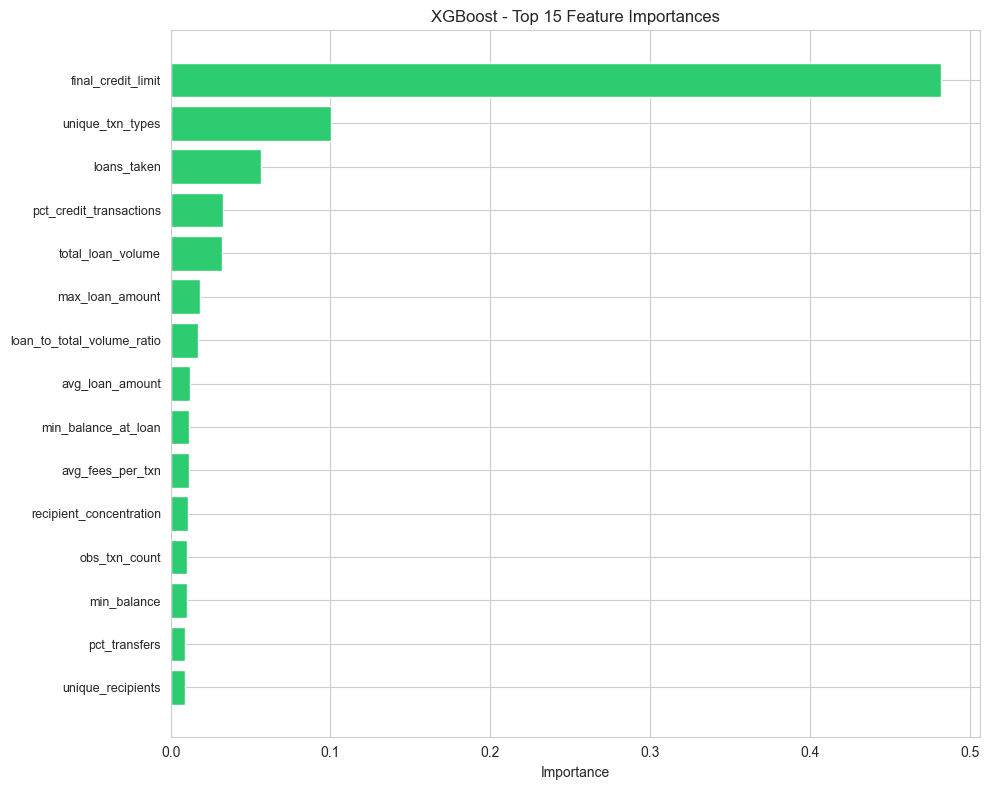

In [5]:
xgb_importance = xgb_model.get_feature_importance(static_data['feature_names'])

fig, ax = plt.subplots(figsize=(10, 8))
top_imp = xgb_importance.head(15)
ax.barh(range(len(top_imp)), top_imp['importance'], color='#2ecc71')
ax.set_yticks(range(len(top_imp)))
ax.set_yticklabels(top_imp['feature'], fontsize=9)
ax.set_xlabel('Importance')
ax.set_title('XGBoost - Top 15 Feature Importances')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Model Comparison

In [6]:
evaluator = ModelEvaluator(static_data['y_test'])
evaluator.add_model('XGBoost', xgb_proba)

comparison = evaluator.get_comparison_table()
print('\nModel Comparison (Test Set):')
print(comparison.round(4).to_string())


Model Comparison (Test Set):
         AUC-ROC  AUC-PR      F1  Precision  Recall  Accuracy
Model                                                        
XGBoost   0.9783  0.8708  0.7647     0.7429  0.7879    0.9463


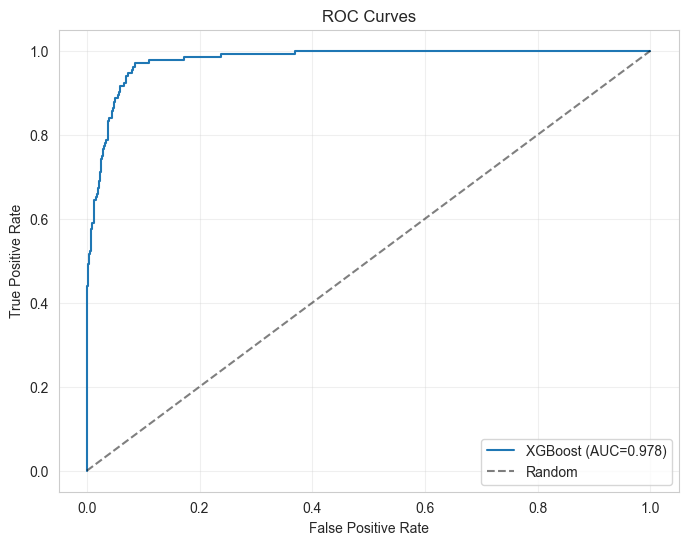

In [7]:
evaluator.plot_roc_curves()
plt.show()

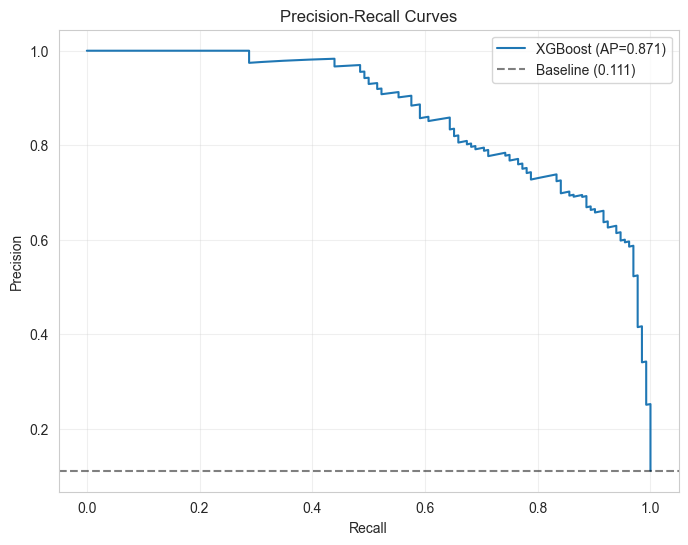

In [8]:
evaluator.plot_pr_curves()
plt.show()

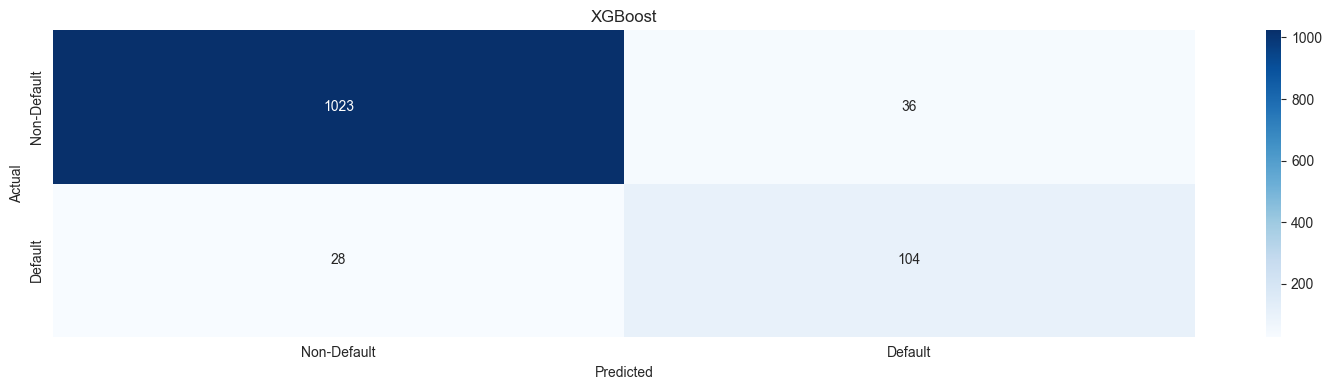

In [9]:
evaluator.plot_confusion_matrices()
plt.show()